# ДЗ №4. Логистическая регрессия (с нуля)

In [6]:
import numpy as np

class LogisticRegression:
    def __init__(self, n_iterations=1000, learning_rate=0.1):
        self.n_iterations = n_iterations
        self.learning_rate = learning_rate
        self.w = None
        self.losses = []  # История функции потерь
        
    def _sigmoid(self, z):
        """Сигмоидная функция"""
        # z = w₀ + w₁x₁ + ... + wₙxₙ
        return 1 / (1 + np.exp(-z))
    
    def log_loss(self, w, X, y):
        """Вычисление функции потерь (log loss) и градиента"""
        m = len(y)
        # Линейная комбинация
        z = X.dot(w)
        # Прогнозы (вероятности)
        predictions = self._sigmoid(z)
        
        epsilon = 1e-15
        predictions = np.clip(predictions, epsilon, 1 - epsilon)
        loss = -1/m * np.sum(y * np.log(predictions) + (1 - y) * np.log(1 - predictions))
        
        grad = 1/m * X.T.dot(predictions - y)
        
        return loss, grad
    
    def optimize(self, w, X, y, n_iterations=None, learning_rate=None):
        """Оптимизация весов с помощью градиентного спуска"""
        if n_iterations is None:
            n_iterations = self.n_iterations
        if learning_rate is None:
            learning_rate = self.learning_rate
            
        losses = []
        current_w = w.copy()
        
        for i in range(n_iterations):
            # Вычисляем потери и градиент
            loss, grad = self.log_loss(current_w, X, y)
            
            # Обновляем веса
            current_w -= learning_rate * grad
            
            losses.append(loss)
            
            if i % 100 == 0:
                print(f"Iteration {i}: Loss = {loss:.6f}")
        
        self.losses = losses
        return current_w, losses
    
    def fit(self, X, y):
        """Обучение модели логистической регрессии"""
        X_bias = np.c_[np.ones((X.shape[0], 1)), X]
        
        initial_w = np.zeros(X_bias.shape[1])
        
        # Обучаем модель
        self.w, self.losses = self.optimize(initial_w, X_bias, y)
        
        return self
    
    def predict_proba(self, X):
        """Предсказание вероятностей принадлежности к классу 1"""
        X_bias = np.c_[np.ones((X.shape[0], 1)), X]
        
        # Вычисляем линейную комбинацию
        z = X_bias.dot(self.w)
        
        return self._sigmoid(z)
    
    def predict(self, X, threshold=0.5):
        """Предсказание классов"""
        # Получаем вероятности
        probabilities = self.predict_proba(X)
        
        # Классифицируем по порогу
        y_predicted = (probabilities >= threshold).astype(int)
        
        return y_predicted
    
    def score(self, X, y):
        """Вычисление точности модели"""
        y_pred = self.predict(X)
        accuracy = np.mean(y_pred == y)
        return accuracy

Iteration 0: Loss = 0.693147
Iteration 100: Loss = 0.273322
Iteration 200: Loss = 0.208832
Iteration 300: Loss = 0.178987
Iteration 400: Loss = 0.160693
Iteration 500: Loss = 0.147920
Iteration 600: Loss = 0.138300
Iteration 700: Loss = 0.130688
Iteration 800: Loss = 0.124453
Iteration 900: Loss = 0.119211
Точность модели: 0.99
Финальное значение потерь: 0.114758


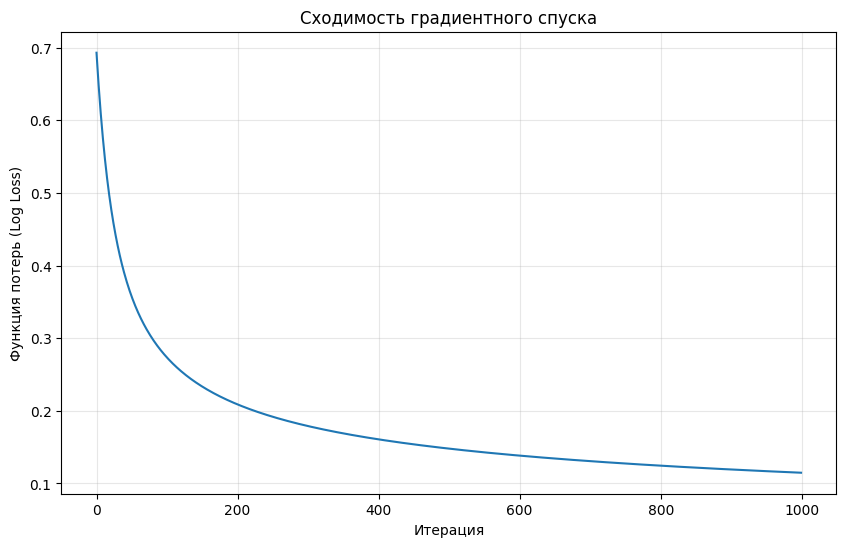

In [8]:
if __name__ == "__main__":
    np.random.seed(42)
    
    m = 100
    X = np.random.randn(m, 2)
    y = (X[:, 0] + X[:, 1] > 0).astype(int)
    
    model = LogisticRegression(n_iterations=1000, learning_rate=0.1)
    model.fit(X, y)

    predictions = model.predict(X)
    
    accuracy = model.score(X, y)
    print(f"Точность модели: {accuracy:.2f}")
    
    print(f"Финальное значение потерь: {model.losses[-1]:.6f}")
    
    import matplotlib.pyplot as plt
    
    plt.figure(figsize=(10, 6))
    plt.plot(model.losses)
    plt.title('Сходимость градиентного спуска')
    plt.xlabel('Итерация')
    plt.ylabel('Функция потерь (Log Loss)')
    plt.grid(True, alpha=0.3)
    
    plt.show()

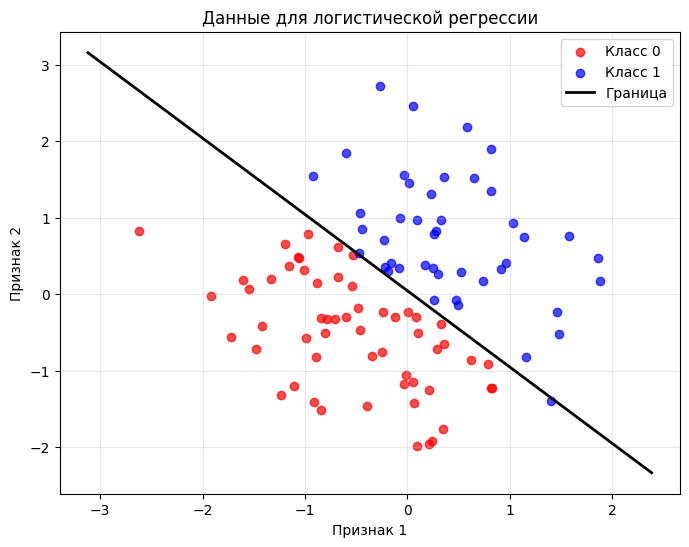

In [9]:
import matplotlib.pyplot as plt

def simple_plot(model, X, y):
    plt.figure(figsize=(8, 6))
    
    # Красные точки для класса 0, синие для класса 1
    plt.scatter(X[y == 0, 0], X[y == 0, 1], color='red', label='Класс 0', alpha=0.7)
    plt.scatter(X[y == 1, 0], X[y == 1, 1], color='blue', label='Класс 1', alpha=0.7)

    w0, w1, w2 = model.w[0], model.w[1], model.w[2]
    
    x1 = np.array([X[:, 0].min() - 0.5, X[:, 0].max() + 0.5])
    x2 = -(w0 + w1 * x1) / w2
    
    plt.plot(x1, x2, 'black', linewidth=2, label='Граница')
    
    plt.xlabel('Признак 1')
    plt.ylabel('Признак 2') 
    plt.title('Данные для логистической регрессии')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

simple_plot(model, X, y)